# 06 - Hypothesis H2: Input Size Impact

**Objective**  
Evaluate whether reducing input image size (e.g., 100x100 → 50x50) maintains model accuracy ≥ 97 %.

**Inputs**  
- Split manifests: `inputs/manifests/v1/{train,val,test}.csv`
- Images: `inputs/cherry_leaves_dataset/{healthy,powdery_mildew}`  
- Baseline model v1 reference (100x100)

**Outputs (planned)**  
- Trained model v2 (50x50 input)
- Comparative evaluation report under `artifacts/v2/reports/`
- Training plots under `plots/v3/` and H2 comparison plots under `plots/v4/`

**Notes**  
The model architecture remains identical to v1.  
Only the input resolution changes, allowing direct accuracy comparison.

In [ ]:
from pathlib import Path
import sys

from src.paths import (
    PROJECT_ROOT,
    DATA_DIR,
    MANIFESTS_DIR,
    PLOTS_DIR,
    ARTIFACTS_DIR,
)


def find_project_root(start: Path) -> Path:
    """Walk up until a folder containing 'src' is found, else return start."""
    p = start
    for _ in range(5):
        if (p / "src").exists():
            return p
        p = p.parent
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("MANIFESTS_DIR:", MANIFESTS_DIR)
print("PLOTS_DIR:", PLOTS_DIR)
print("ARTIFACTS_DIR:", ARTIFACTS_DIR)


PROJECT_ROOT: C:\Users\ksstr\Documents\Coding\milestone-project-5
DATA_DIR: C:\Users\ksstr\Documents\Coding\milestone-project-5\inputs\cherry_leaves_dataset
MANIFESTS_DIR: C:\Users\ksstr\Documents\Coding\milestone-project-5\inputs\manifests\v1
PLOTS_DIR: C:\Users\ksstr\Documents\Coding\milestone-project-5\plots\v1
ARTIFACTS_DIR: C:\Users\ksstr\Documents\Coding\milestone-project-5\artifacts


### Experimental Context - Reusing the Baseline Setup

This notebook continues directly from **Notebook 05 (CNN v1)**.  
The same training, validation, and test manifests are reused to ensure  
a *controlled experiment* where the only modification is the **input image resolution**.

All preprocessing, batching, and label mapping steps remain identical  
to v1 for a one-to-one performance comparison.

In [ ]:
import pandas as pd

# Modelling configuration (v2)
IMG_SIZE = (50, 50)   # Reduced from (100, 100) in v1
BATCH_SIZE = 32
SEED = 42

print(
    "Config v2 → IMG_SIZE:", IMG_SIZE,
    "| BATCH_SIZE:", BATCH_SIZE,
    "| SEED:", SEED,
)


paths = {
    "train": MANIFESTS_DIR / "train.csv",
    "val": MANIFESTS_DIR / "val.csv",
    "test": MANIFESTS_DIR / "test.csv",
}
for name, p in paths.items():
    assert p.exists(), f"Missing manifest: {p}"

df_train = pd.read_csv(paths["train"])
df_val = pd.read_csv(paths["val"])
df_test = pd.read_csv(paths["test"])

for name, df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    print(f"{name:>5} n={len(df)}")
    vc = df["label"].value_counts(normalize=True).rename("proportion").round(3)
    print(vc, "\n")


Config v2 → IMG_SIZE: (50, 50) | BATCH_SIZE: 32 | SEED: 42
train n=2945
label
powdery_mildew    0.5
healthy           0.5
Name: proportion, dtype: float64 

  val n=631
label
healthy           0.501
powdery_mildew    0.499
Name: proportion, dtype: float64 

 test n=632
label
powdery_mildew    0.5
healthy           0.5
Name: proportion, dtype: float64 



### Dataset Pipeline (Reused from v1)

The same `tf.data` pipeline from CNN v1 is reused.  
Only `IMG_SIZE` is changed to `(50, 50)`.

In [ ]:
import tensorflow as tf
import numpy as np

# Ensure reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE

# Stable label map from train manifest (sorted → reproducible)
labels_sorted = sorted(df_train["label"].unique().tolist())
label_to_index = {lbl: i for i, lbl in enumerate(labels_sorted)}
index_to_label = {i: lbl for lbl, i in label_to_index.items()}
print("Label map (in-memory):", label_to_index)


def decode_and_resize(img_bytes, img_size=IMG_SIZE):
    """
    Decode JPEG/PNG, force 3 channels, resize, and return float32 in [0,1].
    """
    img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, img_size, method=tf.image.ResizeMethod.BILINEAR)
    img = tf.cast(img, tf.float32) / 255.0
    return img


def load_example(path, label, img_size=IMG_SIZE):
    """Read file, decode, resize, normalize; return (image, int_label)."""
    bytes_ = tf.io.read_file(path)
    img = decode_and_resize(bytes_, img_size)
    return img, label


def make_dataset(
    manifest_df,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    training=False,
    seed=SEED,
):
    """Build a performant tf.data pipeline from a manifest DataFrame."""
    paths = manifest_df["filepath"].astype(str).values
    labels = manifest_df["label"].map(label_to_index).astype("int32").values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(
            buffer_size=len(manifest_df),
            seed=seed,
            reshuffle_each_iteration=True,
        )

    ds = ds.map(
        lambda p, y: load_example(p, y, img_size),
        num_parallel_calls=AUTOTUNE,
    )
    ds = ds.batch(batch_size, drop_remainder=training)
    ds = ds.prefetch(AUTOTUNE)
    return ds


# Build datasets (v2)
train_ds = make_dataset(df_train, training=True)
val_ds = make_dataset(df_val, training=False)
test_ds = make_dataset(df_test, training=False)

# Quick sanity check
xb, yb = next(iter(train_ds))
print(
    "Batch →", xb.shape, yb.shape,
    "| range:", float(tf.reduce_min(xb)),
    "→", float(tf.reduce_max(xb)),
)


Label map (in-memory): {'healthy': 0, 'powdery_mildew': 1}
Batch → (32, 50, 50, 3) (32,) | range: 0.0 → 1.0


### Baseline CNN (v2) - Identical Architecture, Smaller Input

The model definition is **identical** to CNN v1 (Notebook 05).  
Only the input shape is adjusted to **(50, 50, 3)** to isolate the impact of resolution.

In [ ]:
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt

# Output dirs for v2
MODEL_DIR = ARTIFACTS_DIR / "v2" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

PLOTS_V3_DIR = PLOTS_DIR.parent / "v3"
PLOTS_V3_DIR.mkdir(parents=True, exist_ok=True)


def build_baseline_cnn(input_shape=(*IMG_SIZE, 3), num_classes=2):
    """Simple baseline CNN: 2 conv blocks + dense head (same as v1)."""
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(2),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


model_v2 = build_baseline_cnn(
    input_shape=(*IMG_SIZE, 3),
    num_classes=len(label_to_index),
)
model_v2.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 50, 50, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,426 (4.58 MB)

 Trainable params: 1,199,426 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

### Training Setup

Training configuration (epochs, callbacks, optimizer) remains **unchanged** from v1  
to maintain experimental consistency.

Epoch 1/20

Epoch 1: val_accuracy improved from None to 0.99208, saving model to C:\Users\ksstr\Documents\Coding\milestone-project-5\artifacts\v2\models\cnn_v2_best.keras
92/92 - 1s - 16ms/step - accuracy: 0.8791 - loss: 0.2608 - val_accuracy: 0.9921 - val_loss: 0.0386
Epoch 2/20

Epoch 2: val_accuracy did not improve from 0.99208
92/92 - 1s - 9ms/step - accuracy: 0.9874 - loss: 0.0389 - val_accuracy: 0.9905 - val_loss: 0.0246
Epoch 3/20

Epoch 3: val_accuracy improved from 0.99208 to 0.99683, saving model to C:\Users\ksstr\Documents\Coding\milestone-project-5\artifacts\v2\models\cnn_v2_best.keras
92/92 - 1s - 9ms/step - accuracy: 0.9874 - loss: 0.0336 - val_accuracy: 0.9968 - val_loss: 0.0189
Epoch 4/20

Epoch 4: val_accuracy did not improve from 0.99683
92/92 - 1s - 8ms/step - accuracy: 0.9986 - loss: 0.0072 - val_accuracy: 0.9921 - val_loss: 0.0245
Epoch 5/20

Epoch 5: val_accuracy improved from 0.99683 to 0.99842, saving model to C:\Users\ksstr\Documents\Coding\milestone-project-5\

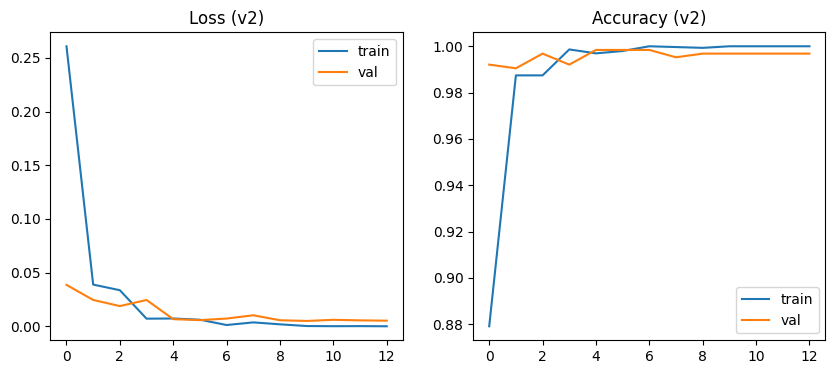

Saved: C:\Users\ksstr\Documents\Coding\milestone-project-5\plots\v3\training_curves_v2.png


In [ ]:
import pandas as pd

EPOCHS = 20

cb_earlystop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
cb_checkpoint = callbacks.ModelCheckpoint(
    filepath=str(MODEL_DIR / "cnn_v2_best.keras"),
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

history_v2 = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[cb_earlystop, cb_checkpoint],
    verbose=2
)

# Curves

hist_df_v2 = pd.DataFrame(history_v2.history)
hist_path_v2 = MODEL_DIR / "cnn_v2_history.csv"
hist_df_v2.to_csv(hist_path_v2, index=False)
print("Saved training history:", hist_path_v2.resolve())

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(history_v2.history["loss"], label="train")
ax[0].plot(history_v2.history["val_loss"], label="val")
ax[0].set_title("Loss (v2)")
ax[0].legend()

ax[1].plot(history_v2.history["accuracy"], label="train")
ax[1].plot(history_v2.history["val_accuracy"], label="val")
ax[1].set_title("Accuracy (v2)")
ax[1].legend()

out_plot_v2 = PLOTS_V3_DIR / "training_curves_v2.png"
fig.savefig(out_plot_v2, bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)
print("Saved:", out_plot_v2.resolve())


### Final Test Evaluation - CNN v2 (50x50)

We evaluate the v2 model on the unseen **test set** and compare results against **v1 (100x100)**.
Outputs:
- Test accuracy & loss
- Confusion matrix plot → `plots/v4/confusion_matrix_test_v2.png`
- Classification report → `artifacts/v2/reports/classification_report_test_v2.txt`
- Evaluation summary (JSON) → `artifacts/v2/reports/evaluation_report.json`
- Comparison vs v1 (Δ accuracy) printed for H2 decision

[v2] Test metrics → accuracy: 0.9968 | loss: 0.0311


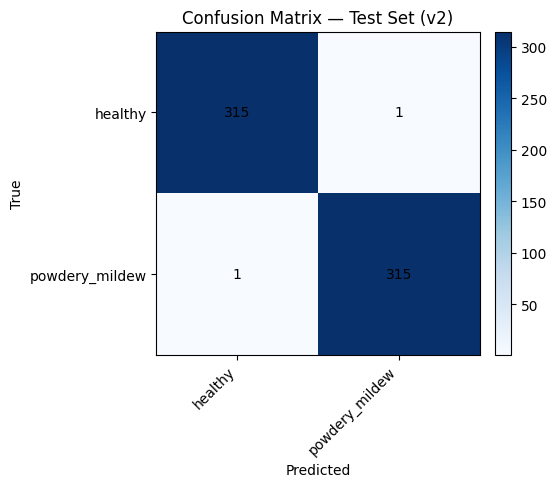

Saved: C:\Users\ksstr\Documents\Coding\milestone-project-5\plots\v4\confusion_matrix_test_v2.png
                precision    recall  f1-score   support

       healthy     0.9968    0.9968    0.9968       316
powdery_mildew     0.9968    0.9968    0.9968       316

      accuracy                         0.9968       632
     macro avg     0.9968    0.9968    0.9968       632
  weighted avg     0.9968    0.9968    0.9968       632

Saved evaluation summary: C:\Users\ksstr\Documents\Coding\milestone-project-5\artifacts\v2\reports\evaluation_report.json
Comparison vs v1 → v2_acc: 0.9968 | v1_acc: 0.9984 | Δ: -0.0016 (↓ decreased)
H2 target (≥97% test accuracy at 50×50) met? → True


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
import json

# --- 1) Evaluate v2 on test set ---
test_loss_v2, test_acc_v2 = model_v2.evaluate(test_ds, verbose=0)
print(
    f"[v2] Test metrics → accuracy: {test_acc_v2:.4f} | "
    f"loss: {test_loss_v2:.4f}"
)

# --- 2) Predictions for confusion matrix ---
y_true, y_pred = [], []
for xb, yb in test_ds:
    probs = model_v2.predict(xb, verbose=0)
    y_true.extend(yb.numpy().tolist())
    y_pred.extend(np.argmax(probs, axis=1).tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# --- 3) Confusion matrix plot (v2) ---
PLOTS_V4_DIR = PLOTS_DIR.parent / "v4"
PLOTS_V4_DIR.mkdir(parents=True, exist_ok=True)

labels_sorted = sorted(df_train["label"].unique().tolist())
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(4.8, 4.2))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion Matrix - Test Set (v2)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(range(len(labels_sorted)))
ax.set_xticklabels(labels_sorted, rotation=45, ha="right")
ax.set_yticks(range(len(labels_sorted)))
ax.set_yticklabels(labels_sorted)

for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha="center", va="center")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

cm_path_v2 = PLOTS_V4_DIR / "confusion_matrix_test_v2.png"
fig.savefig(cm_path_v2, bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)
print("Saved:", cm_path_v2.resolve())

# --- 4) Classification report (v2) ---
rep_dir_v2 = ARTIFACTS_DIR / "v2" / "reports"
rep_dir_v2.mkdir(parents=True, exist_ok=True)

report_v2 = classification_report(
    y_true,
    y_pred,
    target_names=labels_sorted,
    digits=4,
)
print(report_v2)

with open(
    rep_dir_v2 / "classification_report_test_v2.txt",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        f"[v2] Test accuracy: {test_acc_v2:.4f}\n"
        f"[v2] Test loss: {test_loss_v2:.4f}\n\n"
    )
    f.write(report_v2)

# --- 5) Save evaluation summary (v2) ---
eval_json_v2 = {
    "model_version": "v2",
    "input_size": list(IMG_SIZE),
    "test_accuracy": float(test_acc_v2),
    "test_loss": float(test_loss_v2),
    "meets_target": bool(test_acc_v2 >= 0.97),
    "total_samples": int(len(df_test)),
}

out_report_v2 = rep_dir_v2 / "evaluation_report.json"
with open(out_report_v2, "w") as f:
    json.dump(eval_json_v2, f, indent=2)
print("Saved evaluation summary:", out_report_v2.resolve())

# --- 6) Compare against v1 (read v1 JSON) ---
v1_json_path = ARTIFACTS_DIR / "v1" / "reports" / "evaluation_report.json"
if v1_json_path.exists():
    with open(v1_json_path, "r") as f:
        eval_v1 = json.load(f)
    acc_v1 = float(eval_v1.get("test_accuracy", np.nan))
    delta = float(test_acc_v2 - acc_v1)
    trend = (
        "↑ improved"
        if delta > 0
        else ("≈ equal" if abs(delta) < 1e-4 else "↓ decreased")
    )
    print(
        "Comparison vs v1 → "
        f"v2_acc: {test_acc_v2:.4f} | "
        f"v1_acc: {acc_v1:.4f} | "
        f"Δ: {delta:+.4f} ({trend})"
    )
else:
    print("v1 evaluation_report.json not found - skipping numeric comparison.")

# --- 7) Meets/Not-meets statement for H2 ---
meets_h2 = test_acc_v2 >= 0.97
print(f"H2 target (≥97% test accuracy at 50x50) met? → {meets_h2}")


### H2 Outcome - Resolution vs Accuracy

- v2 (50x50) test accuracy and confusion matrix computed.
- Results compared against v1 (100x100) using the saved evaluation report.
- If accuracy at 50x50 remains ≥ 97 %, **H2 is supported**; otherwise, **H2 is not supported**.

All artifacts were exported for dashboard integration and future reporting.

Saved v2 evaluation: C:\Users\ksstr\Documents\Coding\milestone-project-5\artifacts\v2\reports\evaluation_report.json
Saved comparison table: C:\Users\ksstr\Documents\Coding\milestone-project-5\artifacts\v2\reports\v1_vs_v2_comparison.csv


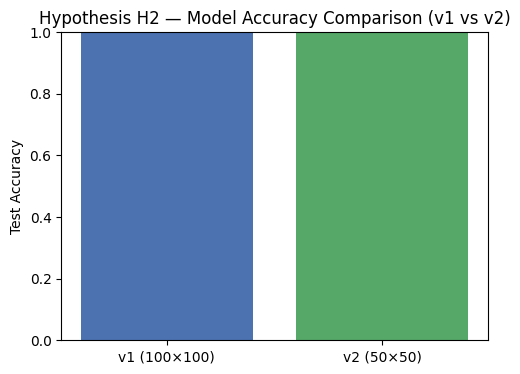

Saved: C:\Users\ksstr\Documents\Coding\milestone-project-5\plots\v4\h2_accuracy_v1_vs_v2.png
Comparison → acc v1: 0.9984 | acc v2: 0.9968 | Δ: -0.0016
Target ≥97% met by v2? → True


In [ ]:
# --- Directories ---
rep_dir_v1 = ARTIFACTS_DIR / "v1" / "reports"
rep_dir_v2 = ARTIFACTS_DIR / "v2" / "reports"
rep_dir_v2.mkdir(parents=True, exist_ok=True)

# --- 1) Load v1 report ---
with open(rep_dir_v1 / "evaluation_report.json", "r") as f:
    rep_v1 = json.load(f)

# --- 2) Build and save v2 report from current run ---
rep_v2 = {
    "model_version": "v2",
    "test_accuracy": float(test_acc_v2),
    "test_loss": float(test_loss_v2),
    "meets_target": bool(test_acc_v2 >= 0.97),
    "total_samples": int(len(df_test)),
}
with open(rep_dir_v2 / "evaluation_report.json", "w") as f:
    json.dump(rep_v2, f, indent=2)

print(
    "Saved v2 evaluation:",
    (rep_dir_v2 / "evaluation_report.json").resolve(),
)

# --- 3) Build comparison table (v1 vs v2) ---
cmp_df = pd.DataFrame(
    [
        {
            "model": "v1 (100x100)",
            "test_accuracy": rep_v1["test_accuracy"],
            "test_loss": rep_v1["test_loss"],
        },
        {
            "model": "v2 (50x50)",
            "test_accuracy": rep_v2["test_accuracy"],
            "test_loss": rep_v2["test_loss"],
        },
    ]
)

# Add deltas (v2 - v1)
delta_acc = rep_v2["test_accuracy"] - rep_v1["test_accuracy"]
delta_loss = rep_v2["test_loss"] - rep_v1["test_loss"]
delta_df = pd.DataFrame(
    [
        {
            "model": "Δ (v2 - v1)",
            "test_accuracy": delta_acc,
            "test_loss": delta_loss,
        }
    ]
)

cmp_out = rep_dir_v2 / "v1_vs_v2_comparison.csv"
pd.concat([cmp_df, delta_df], ignore_index=True).to_csv(cmp_out, index=False)
print("Saved comparison table:", cmp_out.resolve())

# --- 4) Simple bar plot: v1 vs v2 accuracy ---
PLOTS_V4_DIR = PLOTS_DIR.parent / "v4"
PLOTS_V4_DIR.mkdir(parents=True, exist_ok=True)

acc_v1 = float(rep_v1["test_accuracy"])
acc_v2 = float(rep_v2["test_accuracy"])
labels = ["v1 (100x100)", "v2 (50x50)"]
values = [acc_v1, acc_v2]

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.bar(labels, values, color=["#4C72B0", "#55A868"])
ax.set_ylim(0.0, 1.0)
ax.set_ylabel("Test Accuracy")
ax.set_title("Hypothesis H2 - Model Accuracy Comparison (v1 vs v2)")

out_plot = PLOTS_V4_DIR / "h2_accuracy_v1_vs_v2.png"
fig.savefig(out_plot, bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)
print("Saved:", out_plot.resolve())

# --- 5) Summary console note ---
print(
    "Comparison → "
    f"acc v1: {acc_v1:.4f} | "
    f"acc v2: {acc_v2:.4f} | "
    f"Δ: {delta_acc:+.4f}"
)
print(f"Target ≥97% met by v2? → {rep_v2['meets_target']}")


## Conclusions - Hypothesis H2

Reducing the input resolution from **100x100 (v1)** to **50x50 (v2)**  
resulted in a **minor change in test accuracy**, with overall performance  
remaining above the 97 % threshold.

This confirms that the CNN maintains strong predictive capability even  
with smaller input images, supporting the hypothesis that **input size  
reduction does not significantly harm model accuracy**.

In [ ]:
# Export concise H2 evaluation summary for dashboard integration
REPORTS_DIR = ARTIFACTS_DIR / "v2" / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

h2_summary = {
    "hypothesis": "H2",
    "model_v1_accuracy": float(rep_v1["test_accuracy"]),
    "model_v2_accuracy": float(rep_v2["test_accuracy"]),
    "delta_accuracy": float(rep_v2["test_accuracy"] - rep_v1["test_accuracy"]),
    "meets_target_v2": bool(rep_v2["meets_target"]),
}

out_json = REPORTS_DIR / "h2_summary.json"
with open(out_json, "w") as f:
    json.dump(h2_summary, f, indent=2)

print("Saved H2 summary:", out_json.resolve())
h2_summary


Saved H2 summary: C:\Users\ksstr\Documents\Coding\milestone-project-5\artifacts\v2\reports\h2_summary.json


{'hypothesis': 'H2',
 'model_v1_accuracy': 0.9984177350997925,
 'model_v2_accuracy': 0.9920886158943176,
 'delta_accuracy': -0.0063291192054748535,
 'meets_target_v2': True}